In [15]:
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter
from nltk.corpus import stopwords
import nltk

In [18]:
MANUAL_STOP_WORDS = {
    "like", "get", "know", "anyone", "also", "would", "one",
    "since", "going", "got", "really", "time", "feel", "even",
    "still", "back", "take", "go", "much", "new", "need",
    "want", "make", "good", "first", "see", "getting", "went",
    "last", "day", "two", "started", "use", "work", "every", 
    "trying", "week", "could", "think", "never", "way", 
    "something", "taking", "little", "using",
    "things", "long", "always", "around", "lot",
}

nltk.download("stopwords")
STOP_WORDS = set(stopwords.words("english")).union(MANUAL_STOP_WORDS)

SENTIMENT_INPUT_FILE = "data/sentiment_results.csv"
KEYWORD_INPUT_FILE = "data/keyword_results.csv"
OUTPUT_DIR = "outputs/"

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\thecr\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


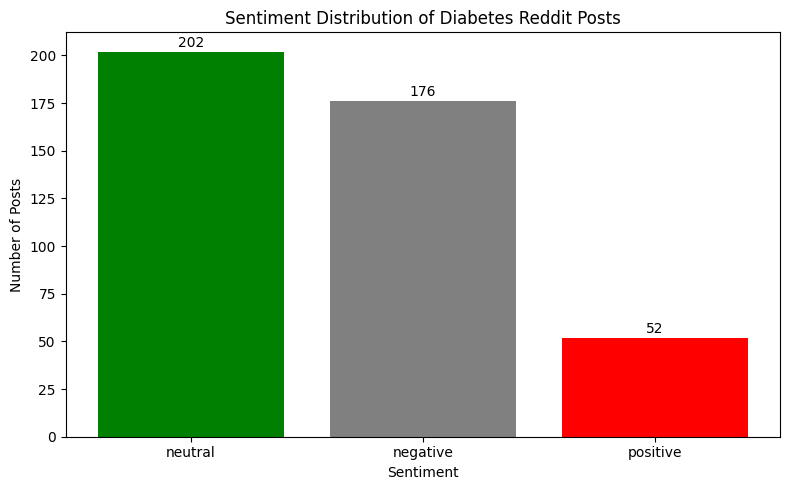

In [19]:

df = pd.read_csv(SENTIMENT_INPUT_FILE)

counts = df["sentiment"].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(counts.index, counts.values, color=["green", "gray", "red"])
ax.set_title("Sentiment Distribution of Diabetes Reddit Posts")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Number of Posts")

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(int(bar.get_height())), ha="center", va="bottom")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}sentiment_distribution.png")
plt.show()

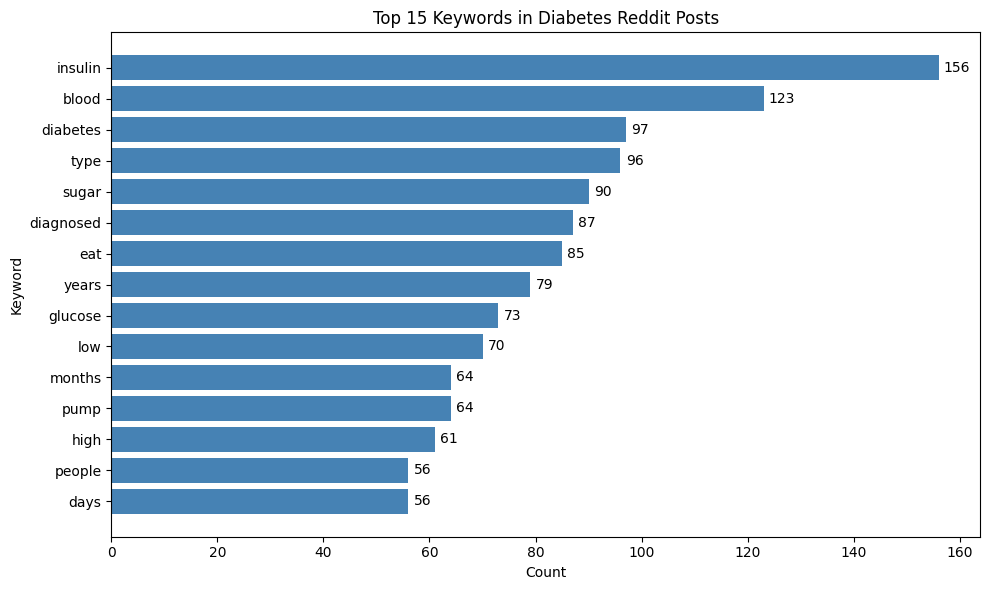

In [20]:
keywords_df = pd.read_csv(KEYWORD_INPUT_FILE)
top15 = keywords_df.head(15)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top15["word"], top15["count"], color="steelblue")

ax.set_title("Top 15 Keywords in Diabetes Reddit Posts")
ax.set_xlabel("Count")
ax.set_ylabel("Keyword")
ax.invert_yaxis()

for bar in bars:
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            str(int(bar.get_width())), va="center")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}top15_keywords.png")
plt.show()

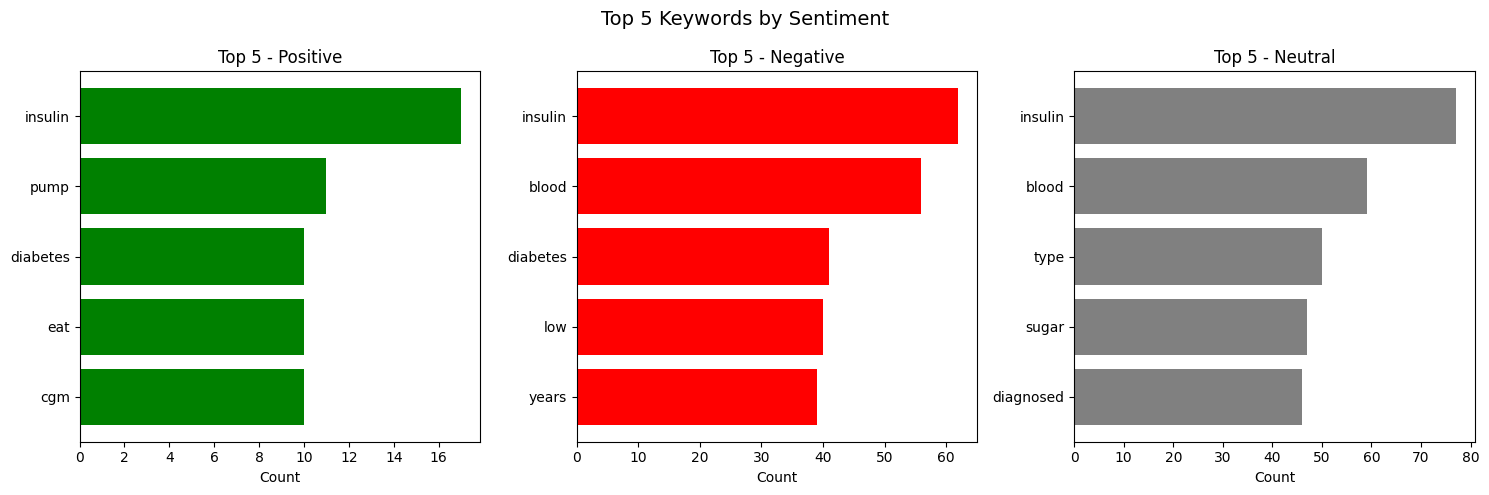

In [21]:
sentiments = ["positive", "negative", "neutral"]
colors = {"positive": "green", "negative": "red", "neutral": "gray"}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, sentiment in zip(axes, sentiments):
    group = df[df["sentiment"] == sentiment]
    all_text = " ".join(group["body_cleaned"].dropna())
    words = [word for word in all_text.lower().split() if word not in STOP_WORDS and len(word) >= 3 and word.isalpha()]
    top5 = Counter(words).most_common(5)
    
    words_list = [w[0] for w in top5]
    counts_list = [w[1] for w in top5]
    
    ax.barh(words_list, counts_list, color=colors[sentiment])
    ax.set_title(f"Top 5 - {sentiment.capitalize()}")
    ax.set_xlabel("Count")
    ax.invert_yaxis()

plt.suptitle("Top 5 Keywords by Sentiment", fontsize=14)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}keywords_by_sentiment.png")
plt.show()

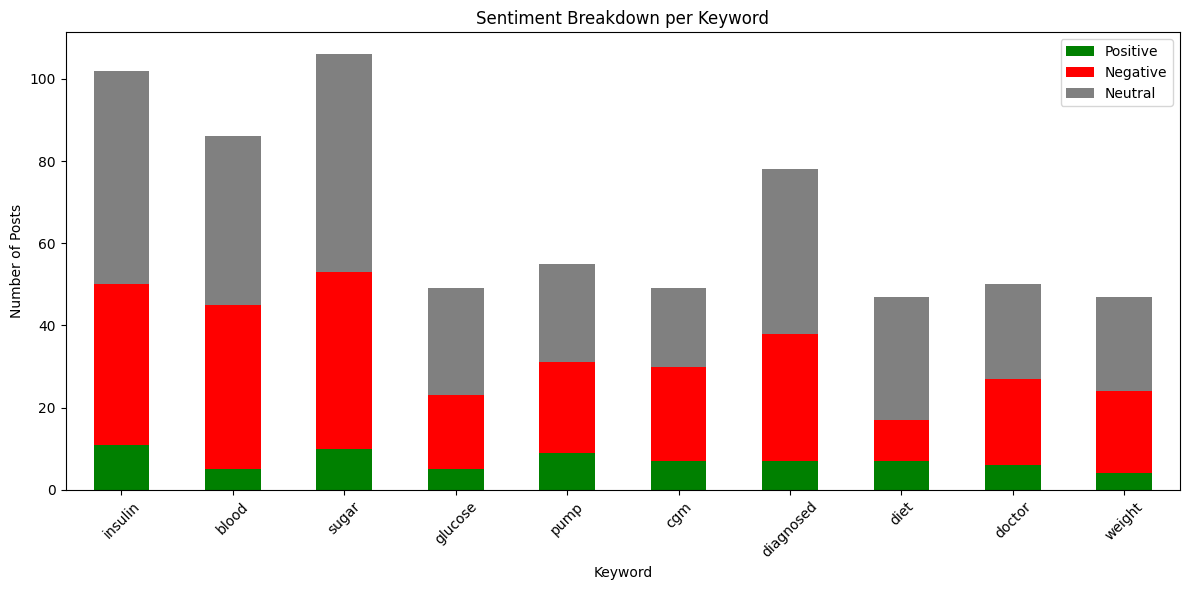

In [23]:
top_keywords = ["insulin", "blood", "sugar", "glucose", "pump", "cgm", "diagnosed", "diet", "doctor", "weight"]

data = []
for keyword in top_keywords:
    keyword_df = df[df["body_cleaned"].str.contains(keyword, case=False, na=False)]
    counts = keyword_df["sentiment"].value_counts()
    data.append({
        "keyword": keyword,
        "positive": counts.get("positive", 0),
        "negative": counts.get("negative", 0),
        "neutral": counts.get("neutral", 0)
    })

keywords_sentiment_df = pd.DataFrame(data)
keywords_sentiment_df.set_index("keyword", inplace=True)

fig, ax = plt.subplots(figsize=(12, 6))
keywords_sentiment_df.plot(kind="bar", stacked=True, color=["green", "red", "gray"], ax=ax)

ax.set_title("Sentiment Breakdown per Keyword")
ax.set_xlabel("Keyword")
ax.set_ylabel("Number of Posts")
ax.legend(["Positive", "Negative", "Neutral"])
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}keyword_sentiment_breakdown.png")
plt.show()